In [1]:
!python -V

Python 3.14.6


In [2]:
%matplotlib inline

In [3]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats

In [4]:
N = 100
T = 200

samples_of_x_bar = np.zeros(T)

In [5]:
for k in np.arange(T):
    uniform_samples = np.random.uniform(low=0.0, high=1.0, size=N)
    samples_of_x_bar[k] = np.mean(uniform_samples)

## Compare the distribution of x_bar with a Gaussian distribution

In [6]:
x_bar_mean  = np.mean(samples_of_x_bar)
x_bar_var   = np.var(samples_of_x_bar, ddof=1)
x_bar_sigma = np.sqrt(x_bar_var)

print(x_bar_mean)
print(x_bar_var)
print(x_bar_sigma)

0.5035940696899938
0.0008437045366405119
0.029046592513417333


In [7]:
np.std(samples_of_x_bar, ddof=1)

np.float64(0.029046592513417333)

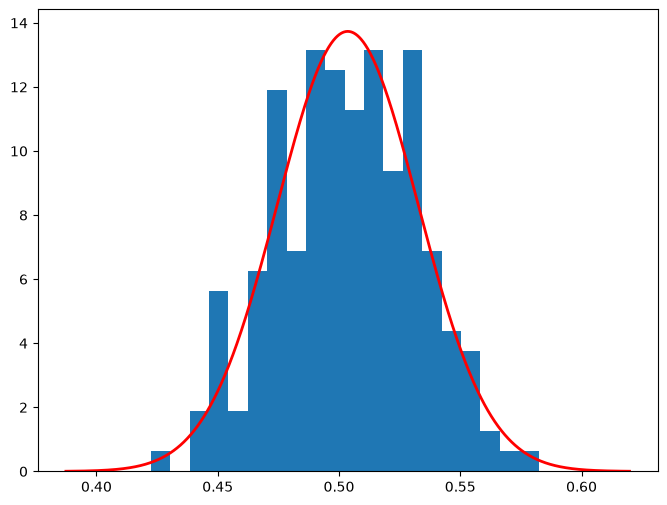

In [8]:
plt.figure(figsize=(8,6))
plt.hist(samples_of_x_bar, bins=20, density=True) # Use "density=True" to make it normalized

x = np.linspace(x_bar_mean - 4*x_bar_sigma, x_bar_mean + 4*x_bar_sigma, 1000)
plt.plot(x, stats.norm.pdf(x, x_bar_mean, x_bar_sigma), color='r', linewidth=2)

plt.show()

## standard deviation (or error) of x_bar

In [9]:
stats.sem(samples_of_x_bar)

np.float64(0.00205390425365998)

In [10]:
x_bar_sigma/np.sqrt(T)

np.float64(0.00205390425365998)

## 95% confidence interval based on CLT

### calculate with the formula

In [11]:
z_factor = stats.norm.ppf(0.975)
print(z_factor)

1.959963984540054


In [12]:
CI_z = [x_bar_mean - z_factor*x_bar_sigma/np.sqrt(T),
        x_bar_mean + z_factor*x_bar_sigma/np.sqrt(T)]

In [13]:
print("The 95% confidence interval based on CLT is:\n", CI_z)

The 95% confidence interval based on CLT is:
 [np.float64(0.4995684913251266), np.float64(0.5076196480548609)]


### calculate with scipy.stats internal function

In [14]:
stats.norm.interval(confidence=0.95,
                    loc=x_bar_mean,
                    scale=stats.sem(samples_of_x_bar)
                   )

(np.float64(0.4995684913251266), np.float64(0.5076196480548609))

## 95% confidence interval based on Student's t-distribution

### calculate with the formula

In [15]:
t_factor = stats.t.ppf(0.975, T-1)
print(t_factor)

1.9719565442517533


In [16]:
CI_t = [x_bar_mean - t_factor*x_bar_sigma/np.sqrt(T),
        x_bar_mean + t_factor*x_bar_sigma/np.sqrt(T)]

In [17]:
print("The 95% confidence interval based on Student's t-distribution is:\n", CI_t)

The 95% confidence interval based on Student's t-distribution is:
 [np.float64(0.49954385975572246), np.float64(0.5076442796242651)]


### calculate with scipt.stats internal function

In [18]:
#create 95% confidence interval for population mean weight
stats.t.interval(confidence=0.95, 
              df=len(samples_of_x_bar)-1, 
              loc=x_bar_mean, 
              scale=stats.sem(samples_of_x_bar)
             )

(np.float64(0.49954385975572246), np.float64(0.5076442796242651))

# Test of the confidence interval with different N and T

In [19]:
uniform_samples = np.random.uniform(low=0.0, high=1.0, size=10000)

def test_CI_N_T(N,T):
    trials = np.array(np.split(uniform_samples, T))
    samples_of_x_bar = np.mean(trials,axis=1)
    
    CI1 = stats.norm.interval(confidence=0.95,
                    loc=np.mean(samples_of_x_bar),
                    scale=stats.sem(samples_of_x_bar)
                   )
    
    CI2 = stats.t.interval(confidence=0.95,
                 df=T-1,
                 loc=np.mean(samples_of_x_bar),
                 scale=stats.sem(samples_of_x_bar)
                )
    
    #print(CI1)
    #print(CI2)
    print(stats.sem(samples_of_x_bar))
    print(np.var(samples_of_x_bar, ddof=1))

In [20]:
test_CI_N_T(20,500)

0.002920441810360617
0.004264490183851198


In [21]:
test_CI_N_T(50,200)

0.002906926516447144
0.0016900443544047054


In [22]:
test_CI_N_T(100,100)

0.0026234154183413147
0.0006882308457190937


In [23]:
test_CI_N_T(500,20)

0.0021705759954425484
9.422800303982822e-05


In [24]:
test_CI_N_T(1000,10)

0.0015018202535648873
2.2554640740177022e-05
